# ADL HW2 - PCA and Autoencoders
In this assignment you will implement two dimensionality reduction schemes
we saw in class:
1. Principal Component Analysis (PCA)
2. Autoencoder

You will also implement an image denoising model to enhance the performance of a simple MLP classifier.

The data used in the following exercises is a subset of the MNIST dataset.
Randomly sample 10,000 images from MNIST train set (you may set a random.seed).

# Submission Date: 05.01.2025
Submit the already-run notebook.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import nn, optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

# EX1. PCA dimensionality reduction (10pts)

1. Implement the PCA procedure in the function ```perform_PCA()```.

Useful functions:
```
sklearn.preprocessing.StandardScaler
scipy.linalg.eigh
numpy.matmul
```
The input should be in vector form (i.e., flatten the input images beforehand).

2. Project the data to 2D, i.e, $\mathbb{R}^{784}↦ \mathbb{R}^2$.
3. Scatter plot the data using the 2D projection and class labels. You'll need to implement ```plot_projected_data()```


In [3]:
from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
import matplotlib.pyplot as plt


def perform_PCA(X, n_components):
  """
  Implement the PCA algorithm.
  Input: X [numpy array] - shape: (N,784)
  Output: Projected data using n_components
  """
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X) # Scaling the data
  cov_matrix = np.cov(X_scaled, rowvar=False) # getting outer product
  eigenvalues, eigenvectors = eigh(cov_matrix)

  #sort the eignvalues

  sorted_indices = np.argsort(eigenvalues)[::-1]
  top_eigenvalues = eigenvalues[sorted_indices[:n_components]]
  top_eigenvectors = eigenvectors[:, sorted_indices[:n_components]]

  X_projected = np.matmul(X_scaled, top_eigenvectors) # projecting x on the top n eigenvectors

  return X_projected


def plot_projected_data(X, y):
  plt.figure(figsize=(8, 6))
  scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
  plt.colorbar(scatter, label='Class Labels')
  plt.title('Projected Data (2D)')
  plt.xlabel('PC 1')
  plt.ylabel('PC 2')
  plt.grid(True)
  plt.show()


In [4]:
# For EX5, Please use the (0.5, 0.5) normalization value, as
# they were used for training the MLP
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST train and test datasets
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)


# Sample 10K images
train_indices = np.random.choice(len(trainset), 10000, replace=False)
train_subset = Subset(trainset, train_indices)

trainloader = DataLoader(train_subset , batch_size=256, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.75MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



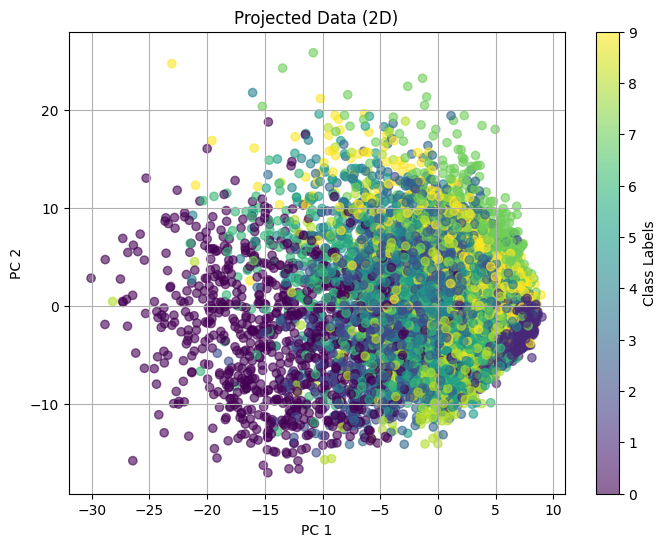

In [5]:
train_images = np.array([image[0].numpy().flatten() for image, _ in train_subset])
train_labels = np.array([label for _, label in train_subset])

X_projected = perform_PCA(train_images, n_components=2)
plot_projected_data(X_projected, train_labels)

# EX2 Autoencoder (AE) (15pts)
1. Implement a fully-connected Autoencoder. The encoder and decoder should have 2 layers each. Use ReLU activation function.
2. The so-called 'code' should be two-dimensional. In other words, the output of the encoder should be 2.
3. Plot the training loss.

4. Project the data using your AE. Plot the data using ```plot_projected_data()```

In [6]:
class MLP_AE(nn.Module):
    def __init__(self):
      super(MLP_AE, self).__init__()
      self.encoder = nn.Sequential(
          nn.Linear(28*28, 128),
          nn.ReLU(),
          nn.Linear(128, 2),
      )
      self.decoder = nn.Sequential(
          nn.Linear(2, 128),
          nn.ReLU(),
          nn.Linear(128, 28*28),
      )

    def forward(self,x):
      x = self.encoder(x)
      x = self.decoder(x)
      return x



In [7]:
def train_autoencoder(model, dataloader, num_epochs, learning_rate, device):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_per_epoch = []
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, _ in dataloader:
            # Flatten the images
            images = images.view(-1, 784).to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, images)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)
        loss_per_epoch.append(epoch_loss)

    return loss_per_epoch

def plot_loss_curve(train_losses, test_losses=None):
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label='Training Loss')
    if test_losses is None:
      plt.title('Training Loss Over Epochs')
    else:
      plt.plot(test_losses, label='Test Loss')
      plt.title('Training and Test Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


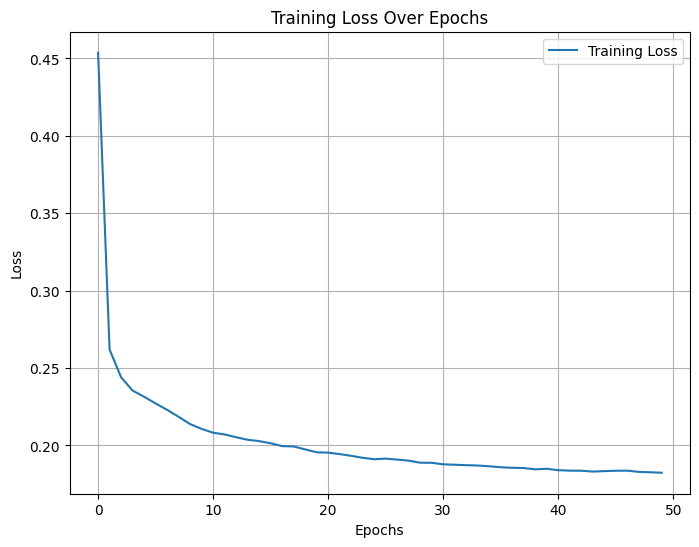

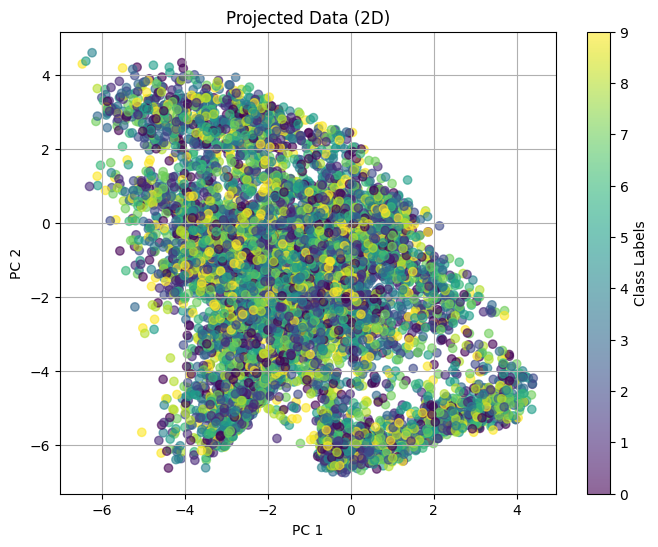

In [8]:
autoencoder = MLP_AE()
trainloader = DataLoader(train_subset, batch_size=256, shuffle=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
losses = train_autoencoder(autoencoder, trainloader, num_epochs=50, learning_rate=0.001, device=device)
plot_loss_curve(losses)

autoencoder.eval()
encoded_data_mlp = []
with torch.no_grad():
    for images, _ in trainloader:
        images = images.view(-1, 784).to(device)
        encoded = autoencoder.encoder(images)
        encoded_data_mlp.append(encoded.cpu())
encoded_data_mlp = torch.cat(encoded_data_mlp).numpy()

plot_projected_data(encoded_data_mlp, train_labels)


# EX3 Linear Autoencoder (15pts)
1. Follow the steps of EX2, but remove the nonlinear activation functions.

4. Project the data using your AE. Plot the data using ```plot_projected_data()```

In [9]:
class Linear_AE(nn.Module):
    def __init__(self):
      super(Linear_AE, self).__init__()
      self.encoder = nn.Sequential(
        nn.Linear(28*28, 128),
        nn.Linear(128, 2),
      )
      self.decoder = nn.Sequential(
          nn.Linear(2, 128),
          nn.Linear(128, 28*28),
      )

    def forward(self,x):
      x = self.encoder(x)
      x = self.decoder(x)
      return x

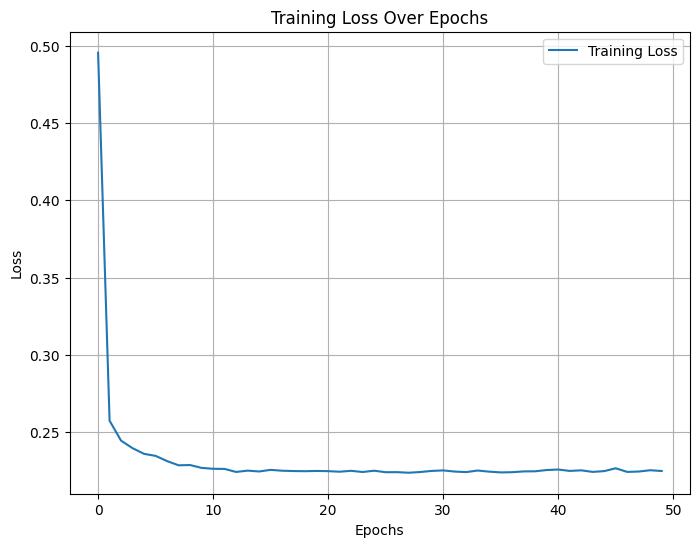

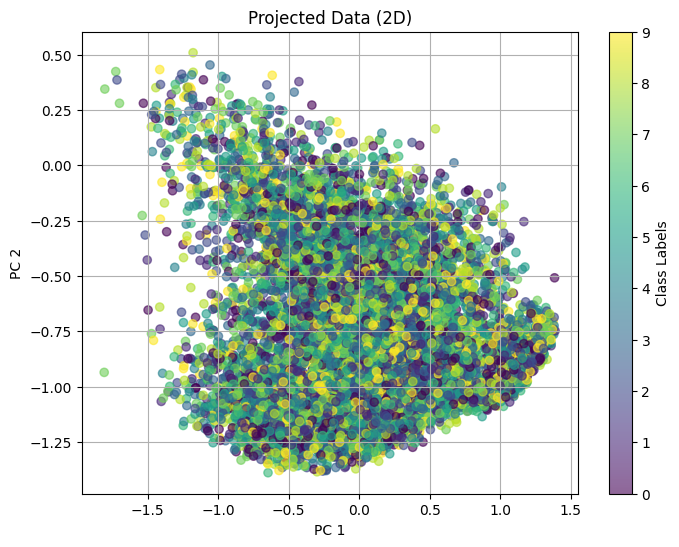

In [10]:
autoencoder = Linear_AE()
trainloader = DataLoader(train_subset, batch_size=256, shuffle=True)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
losses = train_autoencoder(autoencoder, trainloader, num_epochs=50, learning_rate=0.001, device=device)
plot_loss_curve(losses)

autoencoder.eval()
encoded_data_linear = []
image= train_subset[0]

with torch.no_grad():
    for images, _ in trainloader:
        images = images.view(images.size(0), -1).to(device)
        encoded = autoencoder.encoder(images)
        encoded_data_linear.append(encoded.cpu())
encoded_data_linear = torch.cat(encoded_data_linear).numpy()

plot_projected_data(encoded_data_linear, train_labels)



# EX 4 - Discussion (10pts)
1. Write a new plotting function and plot the results side-by-side using subplots.
2. Given the three figures and what we've learned about PCA and AE, answer what are the difference/similarites between the models? How is that indicated in the results?


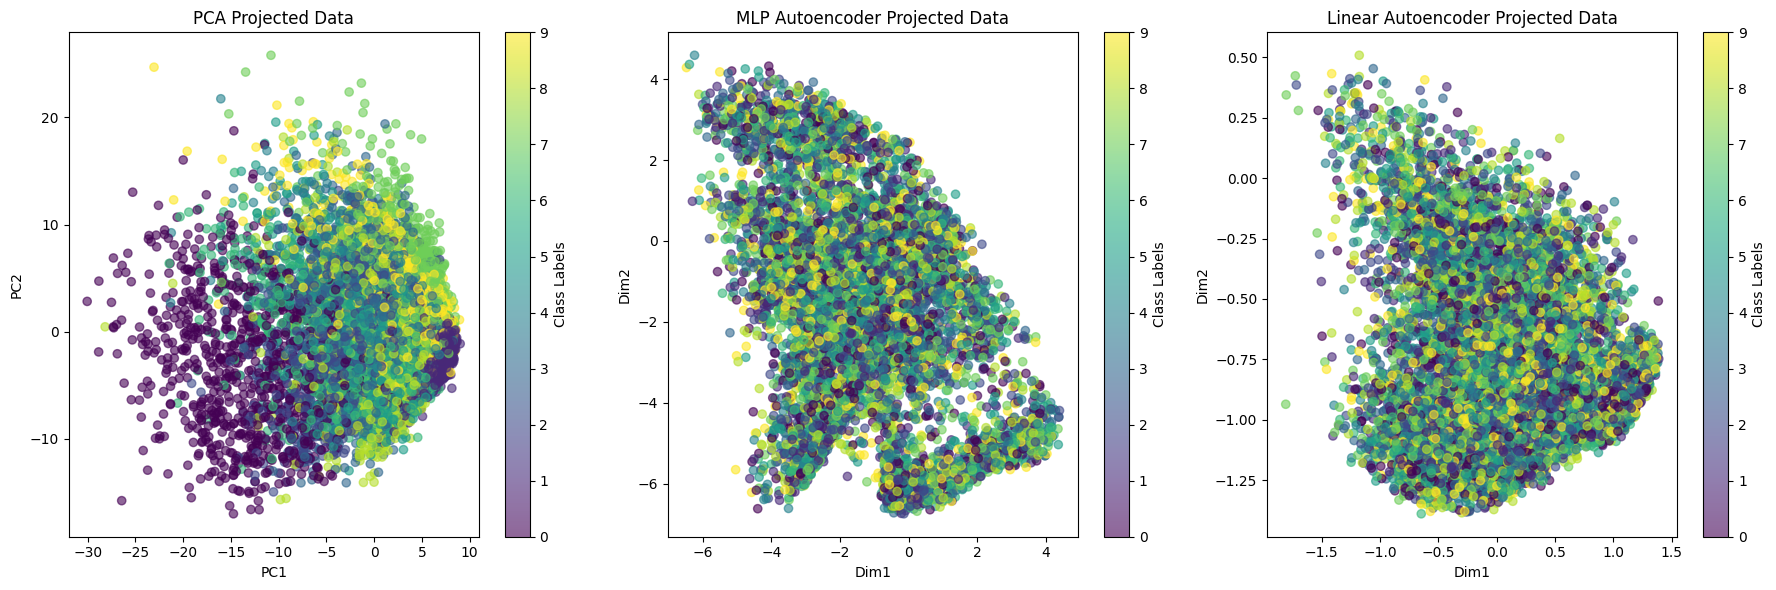

In [11]:
def plot_projected_data_comparison(pca_data, mlp_ae_data, linear_ae_data, labels):

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot PCA Projected Data
    scatter_pca = axes[0].scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axes[0].set_title('PCA Projected Data')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    cbar_pca = plt.colorbar(scatter_pca, ax=axes[0])
    cbar_pca.set_label('Class Labels')

    # Plot MLP Autoencoder Projected Data
    scatter_mlp = axes[1].scatter(mlp_ae_data[:, 0], mlp_ae_data[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axes[1].set_title('MLP Autoencoder Projected Data')
    axes[1].set_xlabel('Dim1')
    axes[1].set_ylabel('Dim2')
    cbar_mlp = plt.colorbar(scatter_mlp, ax=axes[1])
    cbar_mlp.set_label('Class Labels')

    # Plot Linear Autoencoder Projected Data
    scatter_linear = axes[2].scatter(linear_ae_data[:, 0], linear_ae_data[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axes[2].set_title('Linear Autoencoder Projected Data')
    axes[2].set_xlabel('Dim1')
    axes[2].set_ylabel('Dim2')
    cbar_linear = plt.colorbar(scatter_linear, ax=axes[2])
    cbar_linear.set_label('Class Labels')

    plt.tight_layout()
    plt.show()


plot_projected_data_comparison(X_projected, encoded_data_mlp, encoded_data_linear, train_labels)

We can see that in every single method to reduce the dimensions, we get overlapping results between the classes, the pca has some areas of disticnt classes but overall most of the classes are overlapping, we can see that the scale of which the data is shown is different from each method, that may suggest the differ of features captured by the models. overall by looking at the charts and the losses, its easy to say that pca did the best job differing between the classes and then the mlp ae , and at last the linear ae, but none of them did a general good job

# EX 5 - Denoising AE and Classification (50pts.)
In this section you will implement and train a denosing AE to clean corrupted MNIST images.
You are given a trained MLP model (from DL PS1) with ~94% test set accuracy on the cleaned images. Again, work with only 10k images (a subset of the train set).
Your tasks are as follows:
0. Load the mlp.pth file to your project (not google drive dir) and initiate the MLP model with the trained weights.
1. Compute the test set accuracy for the clean and corrupted datasets.
2. Implemented and train autoencoder to remove the noise.
3. Visualize the results for 10 images, one for each digit (original image, corrupted image, clean image).
4. Compute the test set accuracy on the cleaned/denoised corrupted test set. Due to the randomness of the gaussian noise, run the procedure 5 times and take the average accuracy.

You **may not re-train** the classification network or train a new model for classification task.

There is **no need** to submit the trained model weights.

### Grading for this section:
```python
50pts = max(cleaned image accuracy + 10, 100)*0.5 #(i.e, accuracy >= 90% will give you a full grade).
```

You will also be evaluated on the quality of your code and apporach.

## Load trained model

In [13]:
# MLP classifier from DL PS1 - DO NOT CHANGE
mlp_clf = nn.Sequential(nn.Linear(784, 128),
                      nn.ReLU(),
                      nn.Linear(128, 64),
                      nn.ReLU(),
                      nn.Linear(64, 10),
                      nn.LogSoftmax(dim=1))
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_clf = mlp_clf.to(device)

mlp_clf.load_state_dict(torch.load('mlp.pth', map_location=torch.device(device)))


<ipython-input-13-422a21761579>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp_clf.load_state_dict(torch.load('mlp.pth', map_location=torch.device(device)))


<All keys matched successfully>

## Data and functions

In [14]:
# Noise function - DO NOT CHANGE
def add_gaussian_noise(images, mean=0.0, std=2):
    noise = (torch.randn(images.size(), device=images.device) * std + mean)
    noisy_images = images + noise
    return noisy_images


# Accuracy - DO NOT CHANGE
def compute_accuracy(model, testloader, denoise_model=None, add_noise=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            # False for clean images, True for corrupted/noisy
            if add_noise:
              images = add_gaussian_noise(images).to(device)

            # Denoise the image before the classifier
            if denoise_model is not None:
              images = denoise_model(images)
            # reshape to vector form for the MLP
            images = images.view(images.shape[0], -1).to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            labels = labels.to(device)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy



In [15]:
# Compute and print test accuracy for clean and corrupted images
clean_accuracy = compute_accuracy(mlp_clf, testloader, add_noise=False)
corrupted_accuracy = compute_accuracy(mlp_clf, testloader, add_noise=True)

print(f'clean_accuracy:{clean_accuracy}, noisy_imgs_accuracy:{corrupted_accuracy}')

clean_accuracy:93.98, noisy_imgs_accuracy:59.07


In [16]:
class Denoising_AE(nn.Module):
    def __init__(self):
        super(Denoising_AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.BatchNorm2d(32),  # Add batch normalization
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28 -> 14x14
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14x14 -> 7x7
        )

        # Latent: Expanded fully connected layers with dropout
        self.latent = nn.Sequential(
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # Increase dropout
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),  # Latent space
            nn.ReLU(),
        )

        # Decoder: Fully connected layers and transposed convolutions
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 256 * 7 * 7),
            nn.ReLU(),
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.Tanh(),
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)  # Ensure input is 4D
        x = self.encoder(x)
        x = x.view(x.size(0), -1)  # Flatten for latent layer
        x = self.latent(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 256, 7, 7)  # Reshape back to 4D for transposed conv
        x = self.decoder_conv(x)
        return x

def visualize_denoising_results(original, noisy, denoised, n=10):

    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3))
    for i in range(n):
        axes[i, 0].imshow(original[i].reshape(28, 28).cpu(), cmap='gray')
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(noisy[i].reshape(28, 28).cpu(), cmap='gray')
        axes[i, 1].set_title("Noisy")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(denoised[i].reshape(28, 28).cpu(), cmap='gray')
        axes[i, 2].set_title("Denoised")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

import torch.optim as optim

def train_denoise_autoencoder(model, trainloader, testloader, num_epochs, initial_lr, device, patience=5, decay_factor=0.9):
    criterion = nn.MSELoss()
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)

    best_val_loss = float('inf')  # Initialize to a large number
    no_improvement_epochs = 0
    loss_per_epoch_train = []
    loss_per_epoch_val = []

    for epoch in range(num_epochs):
        model.train()
        running_loss_train = 0.0

        # Training phase
        for images, _ in trainloader:
            images = images.to(device)
            noisy_images = add_gaussian_noise(images).to(device)

            outputs = model(noisy_images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss_train += loss.item()

        epoch_loss_train = running_loss_train / len(trainloader)
        loss_per_epoch_train.append(epoch_loss_train)

        # Validation phase
        model.eval()
        running_loss_val = 0.0
        with torch.no_grad():
            for images, _ in testloader:
                images = images.to(device)
                noisy_images = add_gaussian_noise(images).to(device)

                outputs = model(noisy_images)
                loss = criterion(outputs, images)

                running_loss_val += loss.item()

        epoch_loss_val = running_loss_val / len(testloader)
        loss_per_epoch_val.append(epoch_loss_val)

        # Print losses for the epoch
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss_train:.4f}, Validation Loss: {epoch_loss_val:.4f}")

        # Check if validation loss improved
        if epoch_loss_val < best_val_loss:
            best_val_loss = epoch_loss_val
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1

        # If no improvement for `patience` epochs, decay the learning rate
        if no_improvement_epochs >= patience:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= decay_factor  # Reduce learning rate by decay_factor
            print(f"Learning rate reduced to {optimizer.param_groups[0]['lr']:.6f}")
            no_improvement_epochs = 0  # Reset counter

    return loss_per_epoch_train, loss_per_epoch_val


Epoch 1/200, Training Loss: 0.3204, Validation Loss: 0.2570
Epoch 2/200, Training Loss: 0.2535, Validation Loss: 0.2559
Epoch 3/200, Training Loss: 0.2458, Validation Loss: 0.2490
Epoch 4/200, Training Loss: 0.2389, Validation Loss: 0.2271
Epoch 5/200, Training Loss: 0.2155, Validation Loss: 0.2138
Epoch 6/200, Training Loss: 0.1906, Validation Loss: 0.1811
Epoch 7/200, Training Loss: 0.1759, Validation Loss: 0.1622
Epoch 8/200, Training Loss: 0.1659, Validation Loss: 0.1634
Epoch 9/200, Training Loss: 0.1599, Validation Loss: 0.1534
Epoch 10/200, Training Loss: 0.1576, Validation Loss: 0.1450
Epoch 11/200, Training Loss: 0.1523, Validation Loss: 0.1506
Epoch 12/200, Training Loss: 0.1490, Validation Loss: 0.1389
Epoch 13/200, Training Loss: 0.1492, Validation Loss: 0.1338
Epoch 14/200, Training Loss: 0.1443, Validation Loss: 0.1397
Epoch 15/200, Training Loss: 0.1430, Validation Loss: 0.1294
Epoch 16/200, Training Loss: 0.1411, Validation Loss: 0.1360
Epoch 17/200, Training Loss: 0.13

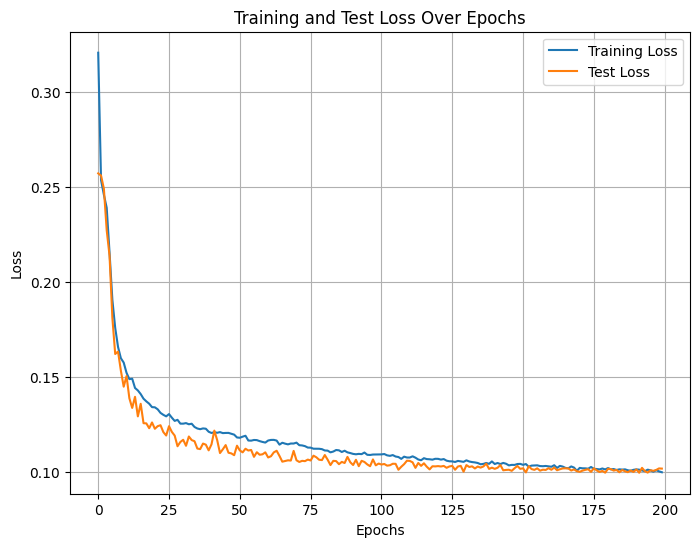

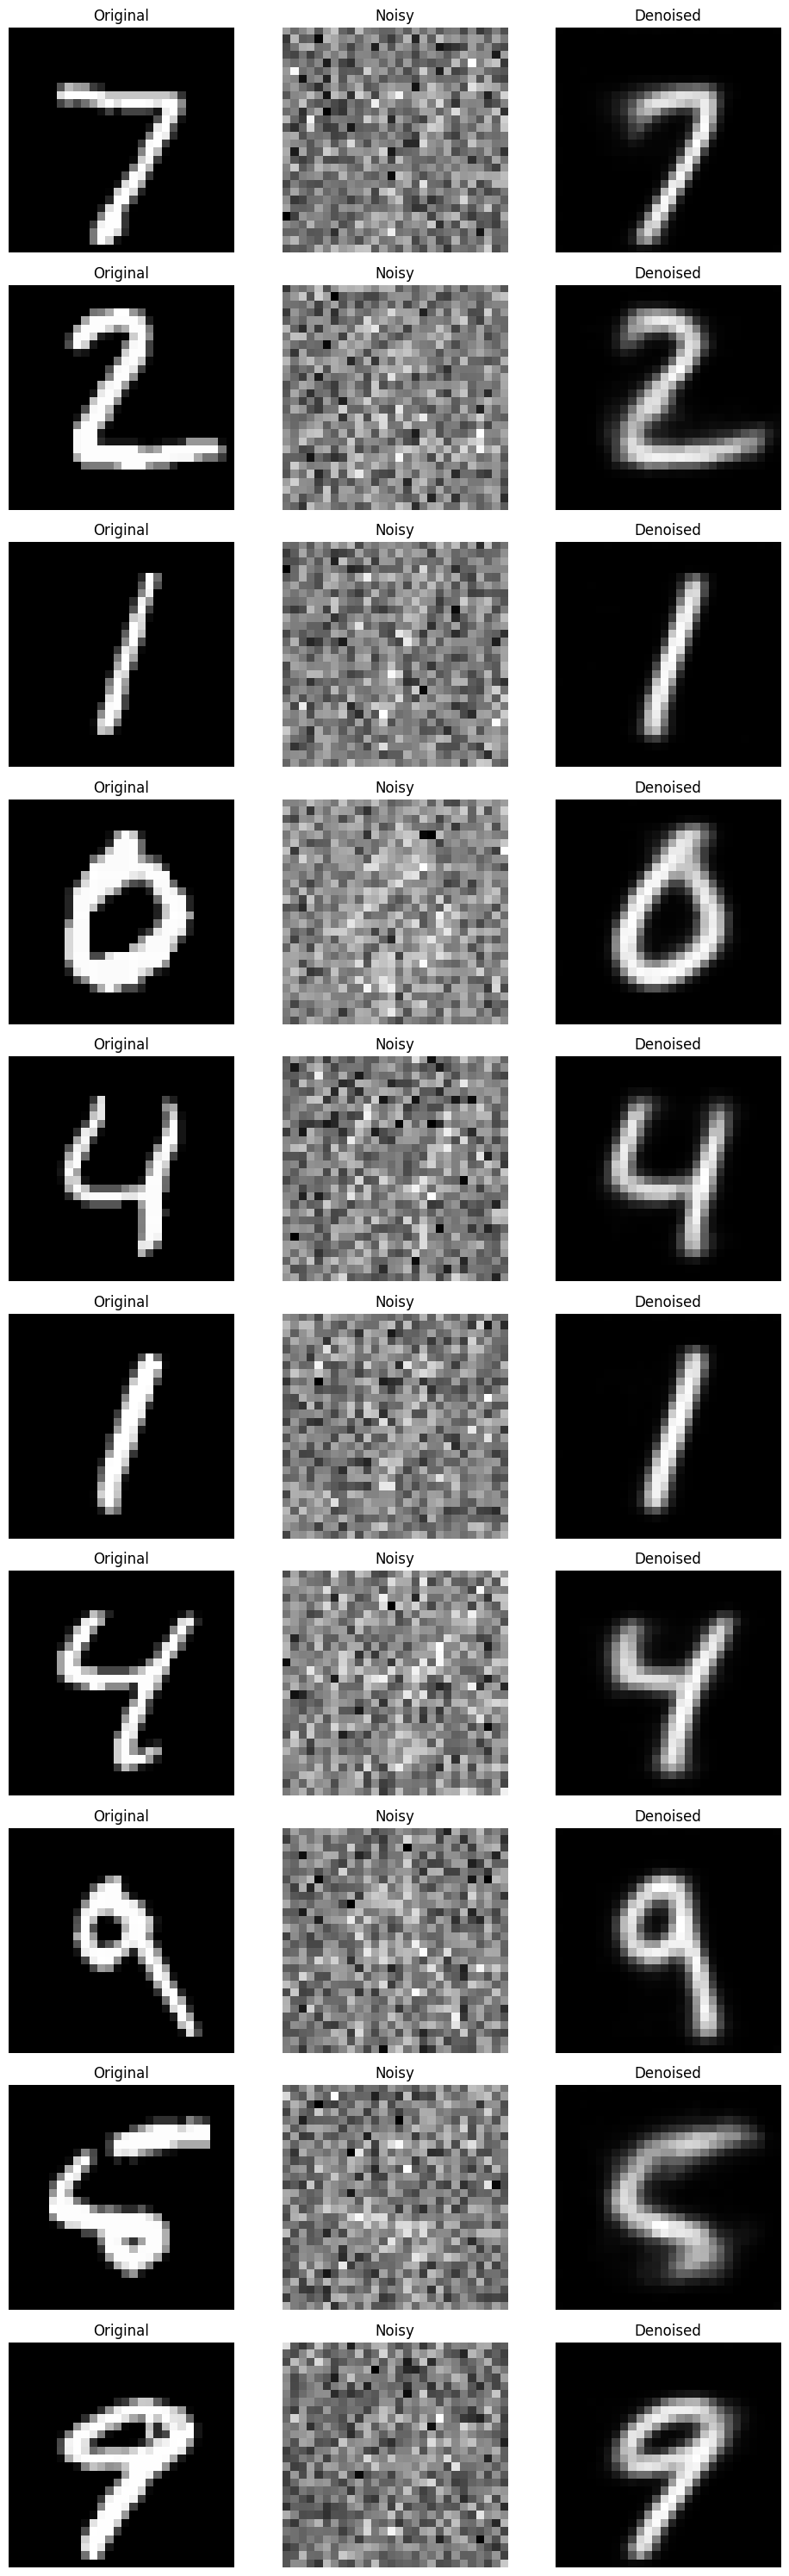

Test Accuracy on Clean Images: 93.98%
Test Accuracy on Noisy Images: 59.16%
Test Accuracy on Denoised Images: 87.17%


In [17]:
denoising_ae = Denoising_AE()
denoising_ae.to(device)
num_epochs=200
lr = 0.001
losses,test_losses = train_denoise_autoencoder(denoising_ae, trainloader,testloader, num_epochs, lr, device)
plot_loss_curve(losses,test_losses)
denoising_ae.eval()
original_images, noisy_images, denoised_images = [], [], []

with torch.no_grad():
        for images, _ in testloader:
            noisy = add_gaussian_noise(images).to(device)
            denoised = denoising_ae(noisy)

            original_images.append(images)
            noisy_images.append(noisy.cpu())
            denoised_images.append(denoised.cpu())

original_images = torch.cat(original_images)[:10]
noisy_images = torch.cat(noisy_images)[:10]
denoised_images = torch.cat(denoised_images)[:10]

# Visualize results
visualize_denoising_results(original_images, noisy_images, denoised_images)

# Compute test accuracy without denoising
clean_accuracy = compute_accuracy(mlp_clf, testloader, add_noise=False)
print(f"Test Accuracy on Clean Images: {clean_accuracy:.2f}%")

noisy_accuracy = compute_accuracy(mlp_clf, testloader, add_noise=True)
print(f"Test Accuracy on Noisy Images: {noisy_accuracy:.2f}%")

# Compute test accuracy with denoising
denoised_accuracy=0
for i in range(5):
  denoised_accuracy += compute_accuracy(mlp_clf, testloader, denoise_model=denoising_ae, add_noise=True)
denoised_accuracy /= 5
print(f"Test Accuracy on Denoised Images: {denoised_accuracy:.2f}%")
